# 06 - Modelo: Feedforward Neural Network (FFNN) con TF-IDF Bigrama

Entrena y evalúa una **red neuronal densa (FFNN)** con PyTorch sobre la
codificación TF-IDF (uni+bigramas) generada en `02_encoding-2.ipynb`.

## Flujo
1. Cargar artefactos TF-IDF.
2. Definir `Dataset` y `DataLoader` para matrices sparse.
3. Definir arquitectura FFNN.
4. Entrenar con `X_tr`, monitorear métricas en `X_val` por época.
5. Evaluar **una sola vez** sobre `X_test_tfidf`.
6. Registrar en MLflow.

## Política de evaluación
| Conjunto | Uso |
|---|---|
| `X_tr` | Entrenamiento por épocas |
| `X_val` | Monitoreo por época (early stopping) |
| `X_train_tfidf` | Entrenamiento final (opcional) |
| `X_test_tfidf` | Evaluación final única |


## 1. Instalación e imports

In [1]:
!pip install -q mlflow
import mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 822.0/822.0 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 20.4 MB/s eta 0:00:00


In [2]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn torch

In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.sparse import load_npz
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

sns.set_theme(style='whitegrid', palette='muted')
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'OK - Imports listos. SEED: {SEED}')
print(f'Device: {DEVICE}')


OK - Imports listos. SEED: 42
Device: cuda


## 2. Carga de artefactos TF-IDF

In [4]:
X_tr          = load_npz('X_tr.npz')
X_val         = load_npz('X_val.npz')
X_train_tfidf = load_npz('X_train_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

INPUT_DIM = X_tr.shape[1]

print('X_tr:          ', X_tr.shape)
print('X_val:         ', X_val.shape)
print('X_train_tfidf: ', X_train_tfidf.shape)
print('X_test_tfidf:  ', X_test_tfidf.shape)
print(f'Input dim:      {INPUT_DIM:,} features')


X_tr:           (1088000, 100000)
X_val:          (272000, 100000)
X_train_tfidf:  (1360000, 100000)
X_test_tfidf:   (240000, 100000)
Input dim:      100,000 features


## 3. Arquitectura FFNN

Una **Feedforward Neural Network** (red densa) es una red sin ciclos donde la
información fluye en una sola dirección: entrada → capas ocultas → salida.

### Arquitectura usada
```
Input (100,000)  →  Dense(512) + BatchNorm + ReLU + Dropout(0.3)
                 →  Dense(256) + BatchNorm + ReLU + Dropout(0.3)
                 →  Dense(128) + BatchNorm + ReLU + Dropout(0.2)
                 →  Dense(1)   + Sigmoid
```

### Decisiones de diseño
| Componente | Razón |
|---|---|
| `BatchNorm` | Estabiliza y acelera el entrenamiento |
| `Dropout` | Regularización para evitar overfitting |
| `ReLU` | Activa no-linealidades sin saturación |
| `Sigmoid` + `BCELoss` | Clasificación binaria |
| `Adam` | Optimizador adaptativo robusto con texto sparse |

### Dataset sparse → dense por batch
Las matrices TF-IDF son sparse (99%+ ceros). Se convierten a tensores
densos **por batch** para no saturar RAM.


## 4. Dataset y DataLoader

In [5]:
class SparseDataset(Dataset):
    """Convierte una matriz sparse a tensores densos por batch."""
    def __init__(self, X_sparse, y):
        self.X = X_sparse
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].toarray().squeeze(), dtype=torch.float32)
        return x, self.y[idx]

BATCH_SIZE = 512

train_ds  = SparseDataset(X_tr,  y_tr)
val_ds    = SparseDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

print(f'Train batches: {len(train_loader):,}')
print(f'Val batches:   {len(val_loader):,}')
print(f'Batch size:    {BATCH_SIZE}')


Train batches: 2,125
Val batches:   532
Batch size:    512


## 5. Definición del modelo

In [6]:
class FFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = FFNN(INPUT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParámetros entrenables: {total_params:,}')


FFNN(
  (net): Sequential(
    (0): Linear(in_features=100000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Parámetros entrenables: 51,366,657


## 6. Entrenamiento con Early Stopping

In [7]:
from tqdm import tqdm
import time

EPOCHS        = 10
LR            = 1e-3
PATIENCE      = 5

criterion  = nn.BCELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_val_loss  = float('inf')
patience_count = 0

def eval_loader(loader, model, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            total_loss += loss.item() * len(y_batch)
            all_preds.extend((preds.cpu().numpy() > 0.5).astype(int))
            all_labels.extend(y_batch.cpu().numpy().astype(int))
    avg_loss = total_loss / len(loader.dataset)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1

epoch_times = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── train con barra de progreso ──
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader, desc=f'Época {epoch:>2}/{EPOCHS} [Train]',
                unit='batch', leave=False, dynamic_ncols=True)

    for X_batch, y_batch in pbar:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y_batch)
        train_preds.extend((preds.detach().cpu().numpy() > 0.5).astype(int))
        train_labels.extend(y_batch.cpu().numpy().astype(int))

        # actualizar barra con loss del batch actual
        pbar.set_postfix({'batch_loss': f'{loss.item():.4f}',
                          'lr': f'{optimizer.param_groups[0]["lr"]:.5f}'})

    pbar.close()

    train_loss /= len(train_loader.dataset)
    train_f1    = f1_score(train_labels, train_preds, average='macro')

    # ── val ──
    val_loss, val_f1 = eval_loader(val_loader, model, criterion, DEVICE)
    scheduler.step(val_loss)

    # ── tiempo y estimación ──
    epoch_time  = time.time() - t0
    epoch_times.append(epoch_time)
    avg_time    = sum(epoch_times) / len(epoch_times)
    epochs_left = EPOCHS - epoch
    eta_seconds = avg_time * epochs_left
    eta_str     = f'{int(eta_seconds // 60)}m {int(eta_seconds % 60)}s'

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    # ── resumen de la época ──
    marker = ' ✅ mejor' if val_loss < best_val_loss else f' ⏳ patience {patience_count+1}/{PATIENCE}'
    print(f'Época {epoch:>2}/{EPOCHS} '
          f'| Train Loss: {train_loss:.4f}  F1: {train_f1:.4f} '
          f'| Val Loss: {val_loss:.4f}  F1: {val_f1:.4f} '
          f'| {epoch_time:.1f}s  ETA: {eta_str}'
          f'{marker}')

    # ── early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'ffnn_best.pt')
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping en época {epoch} — sin mejora en {PATIENCE} épocas')
            break

print(f'\nEntrenamiento completado. Mejor val_loss: {best_val_loss:.4f}')
print(f'Tiempo total: {sum(epoch_times)/60:.1f} min')
print('Mejor modelo guardado en ffnn_best.pt')


Época  1/10 | Train Loss: 0.4265  F1: 0.8030 | Val Loss: 0.4004  F1: 0.8180 | 759.3s  ETA: 113m 53s ✅ mejor


Época  2/10 | Train Loss: 0.3707  F1: 0.8344 | Val Loss: 0.3955  F1: 0.8205 | 755.8s  ETA: 101m 0s ✅ mejor


Época  3/10 | Train Loss: 0.3315  F1: 0.8563 | Val Loss: 0.3974  F1: 0.8214 | 773.5s  ETA: 88m 59s ⏳ patience 1/5


Época  4/10 | Train Loss: 0.2548  F1: 0.8946 | Val Loss: 0.4250  F1: 0.8163 | 772.1s  ETA: 76m 30s ⏳ patience 2/5


Época  5/10 | Train Loss: 0.1877  F1: 0.9239 | Val Loss: 0.4634  F1: 0.8122 | 775.8s  ETA: 63m 56s ⏳ patience 3/5


Época  6/10 | Train Loss: 0.1129  F1: 0.9559 | Val Loss: 0.5900  F1: 0.8112 | 779.0s  ETA: 51m 16s ⏳ patience 4/5


Época  7/10 | Train Loss: 0.0824  F1: 0.9685 | Val Loss: 0.6439  F1: 0.8084 | 767.5s  ETA: 38m 26s ⏳ patience 5/5

Early stopping en época 7 — sin mejora en 5 épocas

Entrenamiento completado. Mejor val_loss: 0.3955
Tiempo total: 89.7 min
Mejor modelo guardado en ffnn_best.pt


### 6.1 Curvas de entrenamiento

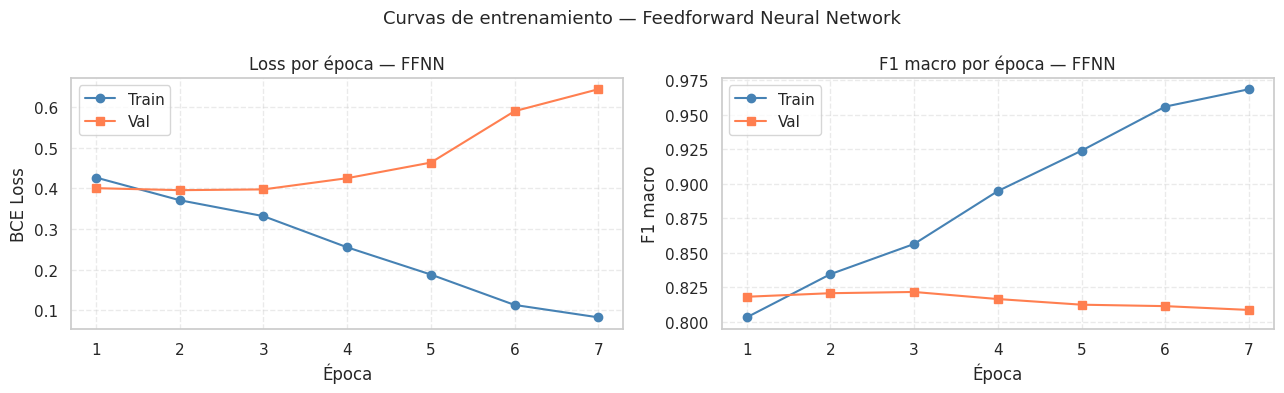

In [8]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs_range, history['train_loss'], marker='o', color='steelblue', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   marker='s', color='coral',     label='Val')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Loss por época — FFNN')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

# F1
axes[1].plot(epochs_range, history['train_f1'], marker='o', color='steelblue', label='Train')
axes[1].plot(epochs_range, history['val_f1'],   marker='s', color='coral',     label='Val')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1 macro')
axes[1].set_title('F1 macro por época — FFNN')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('Curvas de entrenamiento — Feedforward Neural Network', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Evaluación Final en Test

Cargamos el mejor modelo guardado (menor val_loss) y evaluamos en `X_test_tfidf`.


In [12]:
import time

# Cargar mejor modelo
model.load_state_dict(torch.load('ffnn_best.pt', map_location=DEVICE))
model.eval()

def predict_sparse(X_sparse, model, device, batch_size=4096, nombre=''):
    all_preds, all_probas = [], []
    n         = X_sparse.shape[0]
    n_batches = (n + batch_size - 1) // batch_size
    t0        = time.time()

    print(f'  Prediciendo {nombre}: {n:,} filas | {n_batches} batches | batch_size={batch_size}')

    for i, start in enumerate(range(0, n, batch_size)):
        end   = min(start + batch_size, n)
        batch = torch.tensor(X_sparse[start:end].toarray(), dtype=torch.float32).to(device)
        with torch.no_grad():
            proba = model(batch).cpu().numpy()
        all_probas.extend(proba)
        all_preds.extend((proba > 0.5).astype(int))

        # print cada 100 batches
        if (i + 1) % 100 == 0 or (i + 1) == n_batches:
            elapsed    = time.time() - t0
            speed      = (i + 1) / elapsed
            remaining  = (n_batches - (i + 1)) / speed if speed > 0 else 0
            pct        = (i + 1) / n_batches * 100
            barra      = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
            print(f'    [{barra}] {pct:5.1f}%  batch {i+1}/{n_batches}  '
                  f'{elapsed:.0f}s transcurridos  ETA: {remaining:.0f}s')

    total = time.time() - t0
    print(f'  ✅ {nombre} listo en {total:.1f}s\n')
    return np.array(all_preds), np.array(all_probas)

def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1_macro':  f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall':    recall_score(y_true, y_pred, average='macro'),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

print('─' * 55)
print('Iniciando predicciones...')
print('─' * 55)

y_pred_test,  y_proba_test  = predict_sparse(X_test_tfidf,  model, DEVICE, nombre='Test')
y_pred_train, y_proba_train = predict_sparse(X_train_tfidf, model, DEVICE, nombre='Train')
y_pred_val_f, y_proba_val_f = predict_sparse(X_val,         model, DEVICE, nombre='Val')

metrics_test  = get_metrics(y_test,  y_pred_test,  y_proba_test)
metrics_train = get_metrics(y_train, y_pred_train, y_proba_train)
metrics_val   = get_metrics(y_val,   y_pred_val_f, y_proba_val_f)

print('─' * 55)
print('=== EVALUACIÓN FINAL — FFNN + TF-IDF Bigrama ===')
print('─' * 55)
print(f'  Accuracy:  {metrics_test["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics_test["f1_macro"]:.4f}')
print(f'  Precision: {metrics_test["precision"]:.4f}')
print(f'  Recall:    {metrics_test["recall"]:.4f}')
print(f'  ROC-AUC:   {metrics_test["roc_auc"]:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Negativo (0)', 'Positivo (1)']))


───────────────────────────────────────────────────────
Iniciando predicciones...
───────────────────────────────────────────────────────
  Prediciendo Test: 240,000 filas | 59 batches | batch_size=4096
    [████████████████████] 100.0%  batch 59/59  127s transcurridos  ETA: 0s
  ✅ Test listo en 127.3s

  Prediciendo Train: 1,360,000 filas | 333 batches | batch_size=4096
    [██████░░░░░░░░░░░░░░]  30.0%  batch 100/333  207s transcurridos  ETA: 483s
    [████████████░░░░░░░░]  60.1%  batch 200/333  416s transcurridos  ETA: 276s
    [██████████████████░░]  90.1%  batch 300/333  619s transcurridos  ETA: 68s
    [████████████████████] 100.0%  batch 333/333  685s transcurridos  ETA: 0s
  ✅ Train listo en 684.9s

  Prediciendo Val: 272,000 filas | 67 batches | batch_size=4096
    [████████████████████] 100.0%  batch 67/67  136s transcurridos  ETA: 0s
  ✅ Val listo en 135.7s

───────────────────────────────────────────────────────
=== EVALUACIÓN FINAL — FFNN + TF-IDF Bigrama ===
────────────

### 7.1 Gráfica: Métricas Train / Val / Test

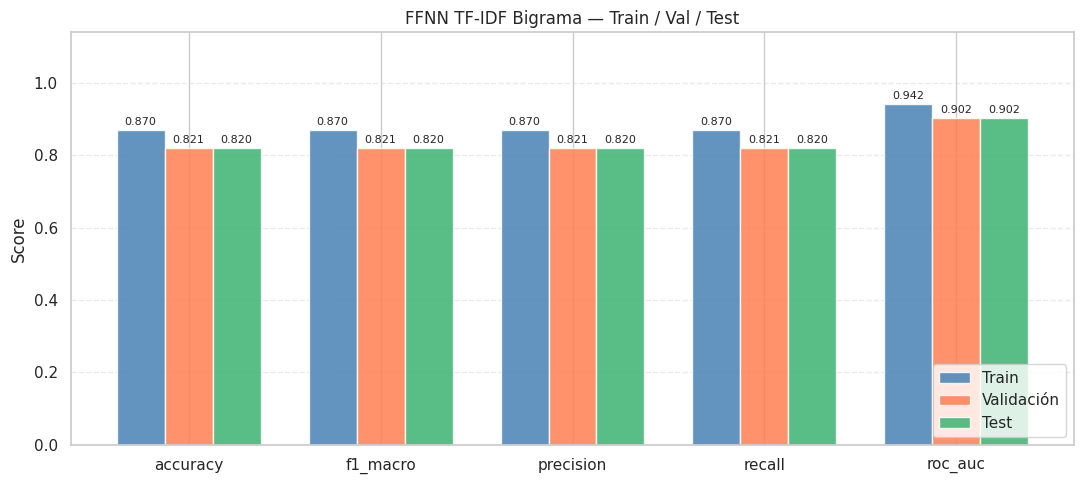

In [13]:
metric_names = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metric_names))
w = 0.25

vals_tr   = [metrics_train[m] for m in metric_names]
vals_val  = [metrics_val[m]   for m in metric_names]
vals_test = [metrics_test[m]  for m in metric_names]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, vals_tr,   w, label='Train',      color='steelblue',      alpha=0.85)
b2 = ax.bar(x,     vals_val,  w, label='Validación', color='coral',          alpha=0.85)
b3 = ax.bar(x + w, vals_test, w, label='Test',       color='mediumseagreen', alpha=0.85)

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.14)
ax.set_ylabel('Score')
ax.set_title('FFNN TF-IDF Bigrama — Train / Val / Test')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 7.2 Matriz de Confusión — Test Final

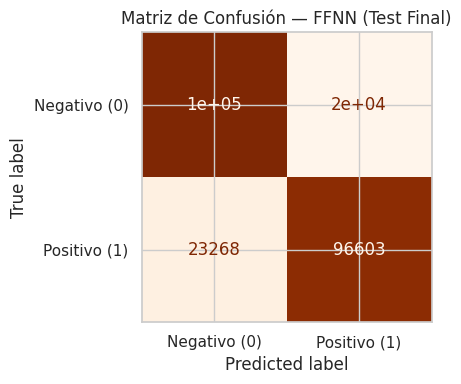

In [14]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo (0)', 'Positivo (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusión — FFNN (Test Final)')
plt.tight_layout()
plt.show()


## 8. Guardar modelo y resultados

In [15]:
# Guardar pesos y arquitectura completa
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim':        INPUT_DIM,
    'architecture':     str(model),
}, 'ffnn_tfidf_model.pt')

results_final = pd.DataFrame([{
    'modelo':      'FFNN',
    'encoding':    'TF-IDF Bigrama',
    'epochs':      len(history['train_loss']),
    'batch_size':  BATCH_SIZE,
    'lr':          LR,
    'train_acc':   round(metrics_train['accuracy'],  4),
    'train_f1':    round(metrics_train['f1_macro'],  4),
    'train_auc':   round(metrics_train['roc_auc'],   4),
    'val_acc':     round(metrics_val['accuracy'],    4),
    'val_f1':      round(metrics_val['f1_macro'],    4),
    'val_auc':     round(metrics_val['roc_auc'],     4),
    'test_acc':    round(metrics_test['accuracy'],   4),
    'test_f1':     round(metrics_test['f1_macro'],   4),
    'test_auc':    round(metrics_test['roc_auc'],    4),
}])

results_final.to_csv('results_ffnn.csv', index=False)
print('Guardados: ffnn_tfidf_model.pt | results_ffnn.csv')
print()
print(results_final.T.to_string(header=False))


Guardados: ffnn_tfidf_model.pt | results_ffnn.csv

modelo                FFNN
encoding    TF-IDF Bigrama
epochs                   7
batch_size             512
lr                   0.001
train_acc           0.8698
train_f1            0.8697
train_auc           0.9421
val_acc             0.8206
val_f1              0.8205
val_auc             0.9024
test_acc            0.8198
test_f1             0.8198
test_auc            0.9024


## 9. Predicción en Vivo

In [16]:
import re

try: vectorizer
except NameError: vectorizer = joblib.load('tfidf_vectorizer.pkl')

try:
    model
except NameError:
    checkpoint = torch.load('ffnn_tfidf_model.pt', map_location=DEVICE)
    model = FFNN(checkpoint['input_dim']).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

def clean_raw_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ════════════════════════════════════════════════════
# ↓↓↓  CAMBIA ESTE TEXTO  ↓↓↓
texto = "I absolutely love this product, it made my day so much better!"
# ════════════════════════════════════════════════════

texto_limpio = clean_raw_text(texto)
X_input      = vectorizer.transform([texto_limpio])
x_tensor     = torch.tensor(X_input.toarray(), dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    proba_pos = model(x_tensor).item()

pred      = 1 if proba_pos > 0.5 else 0
proba     = [1 - proba_pos, proba_pos]
label     = '😊 Positivo' if pred == 1 else '😞 Negativo'
confianza = proba[pred]
barra     = '█' * int(confianza * 30) + '░' * (30 - int(confianza * 30))

print('─' * 50)
print(f'  Texto original : {texto}')
print(f'  Texto limpio   : {texto_limpio}')
print('─' * 50)
print(f'  Predicción     : {label}')
print(f'  Confianza      : {confianza:.1%}  {barra}')
print(f'  P(Negativo)    : {proba[0]:.4f}')
print(f'  P(Positivo)    : {proba[1]:.4f}')
print('─' * 50)


──────────────────────────────────────────────────
  Texto original : I absolutely love this product, it made my day so much better!
  Texto limpio   : I absolutely love this product, it made my day so much better!
──────────────────────────────────────────────────
  Predicción     : 😊 Positivo
  Confianza      : 99.4%  █████████████████████████████░
  P(Negativo)    : 0.0060
  P(Positivo)    : 0.9940
──────────────────────────────────────────────────


## 10. Registro en MLflow

In [17]:
mlflow.set_tracking_uri("http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
mlflow.set_experiment("Parcial_1_NLP")

with mlflow.start_run(run_name="FFNN_TFIDFBigrama") as run:

    # ── Tags ──────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "user":       "Juan Camilo Gallardo",
        "model_type": "FFNN",
        "encoding":   "TF-IDF Bigrama",
        "dataset":    "Sentiment140Twitter",
    })

    # ── Parámetros de preprocesamiento ────────────────────────────────────────
    mlflow.log_params({
        "prep_remove_urls":      True,
        "prep_remove_mentions":  True,
        "prep_remove_hashtags":  True,
        "prep_remove_emojis":    True,
        "prep_remove_stopwords": False,
        "prep_lemmatization":    False,
    })

    # ── Parámetros de codificación ────────────────────────────────────────────
    mlflow.log_params({
        "vec_type":         "TfidfVectorizer",
        "vec_max_features": 100000,
        "vec_min_df":       5,
        "vec_max_df":       0.95,
        "vec_ngram_range":  "(1,2)",
        "vec_sublinear_tf": True,
    })

    # ── Parámetros del modelo ─────────────────────────────────────────────────
    mlflow.log_params({
        "model":        "FFNN",
        "architecture": "512-256-128-1",
        "activation":   "ReLU",
        "dropout":      "0.3/0.3/0.2",
        "batch_norm":   True,
        "optimizer":    "Adam",
        "lr":           LR,
        "batch_size":   BATCH_SIZE,
        "epochs_run":   len(history['train_loss']),
        "patience":     PATIENCE,
        "seed":         SEED,
        "device":       str(DEVICE),
        "train_size":   X_train_tfidf.shape[0],
        "val_size":     X_val.shape[0],
        "test_size":    X_test_tfidf.shape[0],
        "vocab_size":   X_train_tfidf.shape[1],
    })

    # ── Métricas por época (curvas) ───────────────────────────────────────────
    for ep, (tl, vl, tf1, vf1) in enumerate(zip(
        history['train_loss'], history['val_loss'],
        history['train_f1'],   history['val_f1']), start=1):
        mlflow.log_metrics({
            "epoch_train_loss": round(tl,  4),
            "epoch_val_loss":   round(vl,  4),
            "epoch_train_f1":   round(tf1, 4),
            "epoch_val_f1":     round(vf1, 4),
        }, step=ep)

    # ── Métricas Train ────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "train_accuracy":  round(metrics_train['accuracy'],  4),
        "train_f1_macro":  round(metrics_train['f1_macro'],  4),
        "train_precision": round(metrics_train['precision'], 4),
        "train_recall":    round(metrics_train['recall'],    4),
        "train_roc_auc":   round(metrics_train['roc_auc'],   4),
    })

    # ── Métricas Validación ───────────────────────────────────────────────────
    mlflow.log_metrics({
        "val_accuracy":    round(metrics_val['accuracy'],  4),
        "val_f1_macro":    round(metrics_val['f1_macro'],  4),
        "val_precision":   round(metrics_val['precision'], 4),
        "val_recall":      round(metrics_val['recall'],    4),
        "val_roc_auc":     round(metrics_val['roc_auc'],   4),
    })

    # ── Métricas Test ─────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "test_accuracy":   round(metrics_test['accuracy'],  4),
        "test_f1_macro":   round(metrics_test['f1_macro'],  4),
        "test_precision":  round(metrics_test['precision'], 4),
        "test_recall":     round(metrics_test['recall'],    4),
        "test_roc_auc":    round(metrics_test['roc_auc'],   4),
    })

    # ── Artefactos ────────────────────────────────────────────────────────────
    mlflow.log_artifact("results_ffnn.csv")
    mlflow.log_artifact("ffnn_best.pt")

    print("=" * 55)
    print("  ✅ Run registrado en MLflow")
    print(f"  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
    print(f"  Experimento : Parcial_1_NLP")
    print(f"  Corrida     : FFNN_TFIDFBigrama")
    print(f"  Run ID      : {run.info.run_id}")
    print(f"  Test F1     : {metrics_test['f1_macro']:.4f}")
    print(f"  Test AUC    : {metrics_test['roc_auc']:.4f}")
    print("=" * 55)


  ✅ Run registrado en MLflow
  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000
  Experimento : Parcial_1_NLP
  Corrida     : FFNN_TFIDFBigrama
  Run ID      : 7dcf2b872466406ba197e7e7636108e6
  Test F1     : 0.8198
  Test AUC    : 0.9024
🏃 View run FFNN_TFIDFBigrama at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/7dcf2b872466406ba197e7e7636108e6
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1
